<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/main/ajuste_parametros_255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install keras-tcn -q

In [3]:
import tensorflow as tf

print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Primeras filas del dataset:
     hr_sin    hr_cos  weekday_sin  weekday_cos  workingday  temp   atemp  \
0  0.000000  1.000000    -0.781831      0.62349           0  0.24  0.2879   
1  0.258819  0.965926    -0.781831      0.62349           0  0.22  0.2727   
2  0.500000  0.866025    -0.781831      0.62349           0  0.22  0.2727   
3  0.707107  0.707107    -0.781831      0.62349           0  0.24  0.2879   
4  0.866025  0.500000    -0.781831      0.62349           0  0.24  0.2879   

    hum  windspeed  cnt  
0  0.81        0.0   16  
1  0.80        0.0   40  
2  0.80        0.0   32  
3  0.75        0.0   13  
4  0.75        0.0    1  


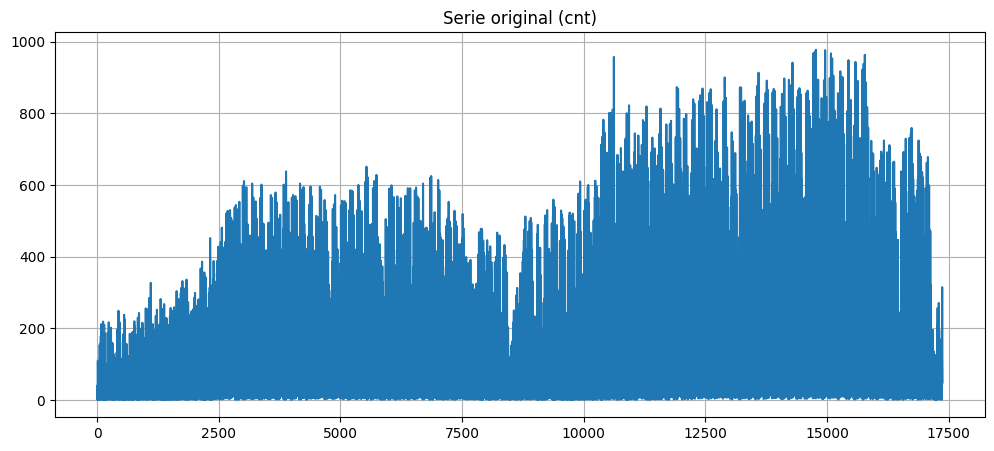

Shapes:
X_train: (12131, 48, 10) y_train: (12131,)
X_val: (2600, 48, 10) y_val: (2600,)
X_test: (2600, 48, 10) y_test: (2600,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Entrenando TCN...
Epoch 1/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 103s 135ms/step - loss: 2.1275 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 2/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0203 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 3/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0152 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 4/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0126 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 5/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0100 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 6/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0076 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 7/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0061 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 8/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0052 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 9/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0044 - val_lo

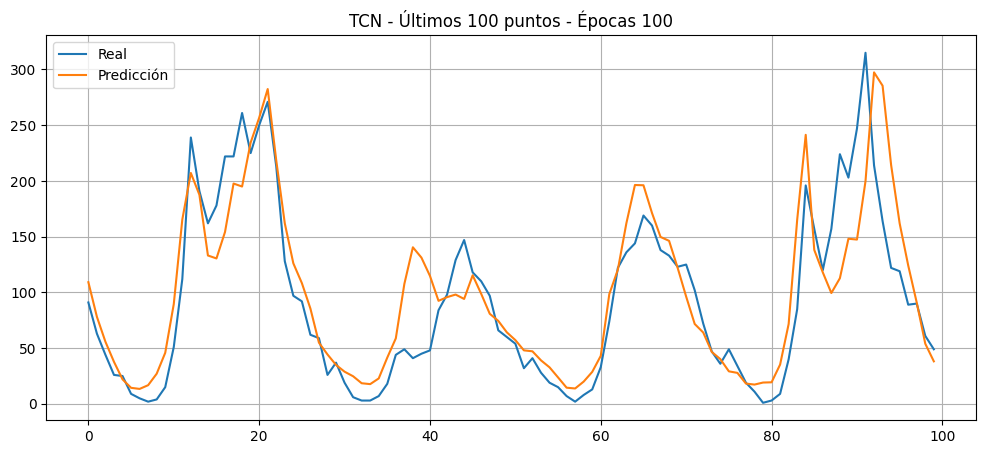

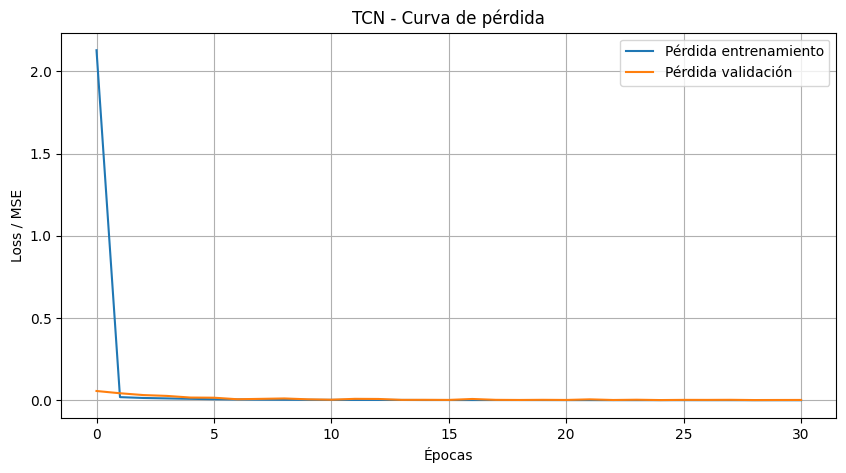

Tabla comparativa:
         MAE        MSE     RMSE     MAPE    sMAPE
TCN  32.9575  2478.8927  49.7885  64.2605  30.8795
Generando gráfica comparativa...


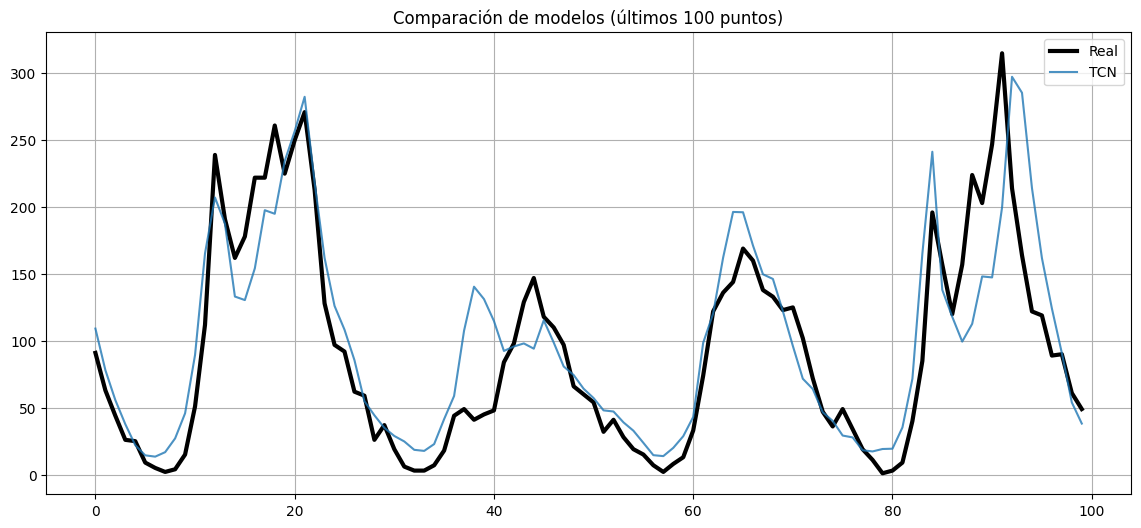

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from keras.models import Model, Sequential
from keras.layers import (
    Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D,
    Flatten, Input, RepeatVector, Dropout, InputLayer
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN


def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, -1])   # última columna = target
    return np.array(X), np.array(y)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )


# ============================================================
# MODELOS ORIGINALES
# Se dejan en el código, pero no se usarán en esta actividad.
# La instrucción pide entrenar solamente TCN para ajustar sus parámetros.
# ============================================================

# def buildRNN(input_shape):
#     model = Sequential([
#         SimpleRNN(64, activation='tanh', input_shape=input_shape),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse')
#     return model


# def buildLSTM(input_shape):
#     model = Sequential([
#         LSTM(64, input_shape=input_shape),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse')
#     return model


# def buildGRU(input_shape):
#     model = Sequential([
#         GRU(64, input_shape=input_shape),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse')
#     return model


# def buildSeq2Seq(input_shape):
#     encoder_inputs = Input(shape=input_shape)
#     encoder = LSTM(64, return_state=True)
#     encoder_outputs, state_h, state_c = encoder(encoder_inputs)

#     decoder_inputs = RepeatVector(1)(encoder_outputs)
#     decoder = LSTM(64)(decoder_inputs)

#     outputs = Dense(1)(decoder)

#     model = Model(encoder_inputs, outputs)
#     model.compile(optimizer='adam', loss='mse')
#     return model


# def buildCNN1D(input_shape):
#     model = Sequential([
#         Conv1D(64, 3, activation='relu', input_shape=input_shape),
#         MaxPooling1D(2),
#         Flatten(),
#         Dense(50, activation='relu'),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse')
#     return model


# ============================================================
# MODELO TCN AJUSTADO
# Este es el único modelo que se entrenará.
# ============================================================

def buildTCN(input_shape):
    model = Sequential([
        InputLayer(input_shape=input_shape),
        TCN(
            nb_filters=128,
            kernel_size=5,
            dilations=(1, 2, 4, 8, 16, 32, 64),
            nb_stacks=2,
            padding='causal',
            use_skip_connections=True,
            dropout_rate=0.03,
            return_sequences=False,
            activation='relu',
            use_layer_norm=True
        ),
        Dense(64, activation='relu'),
        Dropout(0.03),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model


def plot_all_models(y_true, predictions_dict, N=200):
    plt.figure(figsize=(14, 6))

    plt.plot(y_true[-N:], label="Real", linewidth=3, color='black')

    for name, preds in predictions_dict.items():
        plt.plot(preds[-N:], label=name, alpha=0.8)

    plt.title(f"Comparación de modelos (últimos {N} puntos)")
    plt.legend()
    plt.grid()
    plt.show()


def inverse_transform_target(scaler, values_scaled, n_features):
    temp = np.zeros((len(values_scaled), n_features))
    temp[:, -1] = values_scaled.reshape(-1)
    temp_inv = scaler.inverse_transform(temp)
    return temp_inv[:, -1]


def evaluate_and_plot(
    models,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    scaler, df,
    epochs, batch, plot_points
):
    results = {}
    predictions_all = {}

    for name, model in models.items():
        print(f"Entrenando {name}...")

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        )

        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=0.00001,
            verbose=1
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch,
            verbose=1,
            callbacks=[early_stop, reduce_lr]
        )

        preds = model.predict(X_test, verbose=0)

        # Inversa del target real
        y_test_inv = inverse_transform_target(
            scaler, y_test, df.shape[1]
        )

        # Inversa de predicciones
        preds_inv = inverse_transform_target(
            scaler, preds.reshape(-1), df.shape[1]
        )

        predictions_all[name] = preds_inv

        results[name] = {
            "MAE": mae(y_test_inv, preds_inv),
            "MSE": mse(y_test_inv, preds_inv),
            "RMSE": rmse(y_test_inv, preds_inv),
            "MAPE": mape(y_test_inv, preds_inv),
            "sMAPE": smape(y_test_inv, preds_inv),
        }

        # Gráfica individual: valores reales vs predicción
        plt.figure(figsize=(12, 5))
        plt.plot(y_test_inv[-plot_points:], label="Real")
        plt.plot(preds_inv[-plot_points:], label="Predicción")
        plt.title(
            name + " - Últimos " + str(plot_points) +
            " puntos - Épocas " + str(epochs)
        )
        plt.legend()
        plt.grid()

        fig = plt.gcf()
        fig.savefig(
            name + " - Últimos " + str(plot_points) +
            " puntos - Epocas " + str(epochs) + ".jpeg",
            bbox_inches='tight'
        )

        plt.show()

        # Gráfica de pérdida del entrenamiento
        plt.figure(figsize=(10, 5))
        plt.plot(history.history['loss'], label='Pérdida entrenamiento')
        plt.plot(history.history['val_loss'], label='Pérdida validación')
        plt.title(name + " - Curva de pérdida")
        plt.xlabel("Épocas")
        plt.ylabel("Loss / MSE")
        plt.legend()
        plt.grid()
        plt.show()

    return results, y_test_inv, predictions_all


if __name__ == "__main__":
    # ============================================================
    # PARÁMETROS GENERALES
    # ============================================================

    DATA_PATH = "/content/drive/MyDrive/ClassFiles/Metodos_de_Pronostico/hour.csv"
    FEATURES = [
        'hr_sin', 'hr_cos',
        'weekday_sin', 'weekday_cos',
        'workingday',
        'temp', 'atemp', 'hum', 'windspeed',
        'cnt'
    ]

    WINDOW_SIZE = 48 # 24 fue la primer prueba con RMSE = 57.0539

    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15

    # Se aumenta el número de épocas para que el modelo TCN pueda aprender mejor.
    # EarlyStopping detendrá el entrenamiento si ya no hay mejora.
    EPOCHS = 100

    BATCH_SIZE = 32
    PLOT_POINTS = 100

    # ============================================================
    # LECTURA Y PREPARACIÓN DEL DATASET
    # ============================================================

    df = pd.read_csv(DATA_PATH)

    df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
    df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

    df = df[FEATURES]

    print("Primeras filas del dataset:")
    print(df.head())

    # Escalado de variables
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(df)

    # Gráfica de la serie original
    plt.figure(figsize=(12, 5))
    plt.plot(df['cnt'])
    plt.title("Serie original (cnt)")
    plt.grid()
    plt.show()

    # Creación de secuencias
    X, y = create_sequences(data_scaled, WINDOW_SIZE)

    n = len(X)
    train_end = int(n * TRAIN_SIZE)
    val_end = int(n * (TRAIN_SIZE + VAL_SIZE))

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    print("Shapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

    input_shape = X_train.shape[1:]

    # ============================================================
    # MODELOS A ENTRENAR
    # ============================================================
    # Para esta actividad solo se entrenará TCN.
    # Los demás modelos se comentan, no se eliminan.

    models = {
        # "RNN": buildRNN(input_shape),
        # "LSTM": buildLSTM(input_shape),
        # "GRU": buildGRU(input_shape),
        # "Seq2Seq": buildSeq2Seq(input_shape),
        # "CNN1D": buildCNN1D(input_shape),

        "TCN": buildTCN(input_shape)
    }

    # ============================================================
    # ENTRENAMIENTO Y EVALUACIÓN
    # ============================================================

    results, y_true_inv, predictions_all = evaluate_and_plot(
        models,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        scaler, df,
        EPOCHS,
        BATCH_SIZE,
        PLOT_POINTS
    )

    # ============================================================
    # TABLA COMPARATIVA
    # Como solo está activo TCN, la tabla mostrará únicamente TCN.
    # ============================================================

    print("Tabla comparativa:")
    results_df = pd.DataFrame(results).T
    results_df = results_df.sort_values(by="RMSE")
    print(results_df.round(4))

    # ============================================================
    # GRÁFICA COMPARATIVA FINAL
    # Como solo está activo TCN, la gráfica mostrará Real vs TCN.
    # ============================================================

    print("Generando gráfica comparativa...")
    plot_all_models(y_true_inv, predictions_all, PLOT_POINTS)